# Cài thư viện cần thiết

In [38]:
!pip install -q \
    pandas \
    numpy \
    matplotlib \
    seaborn \
    scikit-learn \
    plotly \
    geopandas \
    wbdata \
    requests \
    openpyxl \
    pandas_datareader \
    statsmodels



In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import silhouette_score, r2_score, mean_squared_error
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Cấu hình matplotlib để hiển thị tiếng Việt
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
sns.set_style("whitegrid")

# Nạp thư viện và Lấy dữ liệu

## nạp data thô

In [ ]:
import pandas as pd
from pathlib import Path
ROOT = Path.cwd()
PATTERNS = {
    "Mobile_Subscriptions": "API_IT.CEL.SETS.P2*.csv",
    "Internet_Users":       "API_IT.NET.USER.ZS*.csv",
    "GDP_per_Capita":       "API_NY.GDP.PCAP.CD*.csv",
    "Labor_Productivity":   "API_SL.GDP.PCAP.EM.KD*.csv",
}


In [ ]:

def find_file(pattern: str) -> Path | None:
    matches = list(ROOT.rglob(pattern))
    return matches[0] if matches else None

paths = {}
for key, pat in PATTERNS.items():
    p = find_file(pat)
    if p is None:
        print(f"❌ Chưa tìm thấy file cho: {key} | pattern: {pat}")
    else:
        paths[key] = p
        print(f" Found {key}: {p.relative_to(ROOT)}")
        
missing = [k for k in PATTERNS if k not in paths]
print("\nThiếu:", missing if missing else "Không, đã đủ 4 file.")


✅ Found Mobile_Subscriptions: wb_csv\API_IT.CEL.SETS.P2_DS2_en_csv_v2_123929.csv
✅ Found Internet_Users: wb_csv\API_IT.NET.USER.ZS_DS2_en_csv_v2_129784.csv
✅ Found GDP_per_Capita: wb_csv\API_NY.GDP.PCAP.CD_DS2_en_csv_v2_134819.csv
✅ Found Labor_Productivity: wb_csv\API_SL.GDP.PCAP.EM.KD_DS2_en_csv_v2_4378.csv

Thiếu: Không, đã đủ 4 file.


In [ ]:

def detect_header_row(fp: Path) -> int:
    with fp.open("r", encoding="utf-8-sig", errors="ignore") as f:
        for i, line in enumerate(f):
            if i > 50:
                break
            first = line.strip().lstrip("\ufeff").strip('"').lower()
            if first.startswith("country name"):
                return i
    return 4  

def load_wb_raw(fp: Path) -> pd.DataFrame:
    hdr = detect_header_row(fp)
    for skip in [hdr, max(hdr-1, 0), hdr+1, 4, 0]:
        try:
            df = pd.read_csv(fp, skiprows=skip, encoding="utf-8-sig", low_memory=False)
            df = df.loc[:, ~df.columns.str.contains(r"^Unnamed", case=False)]
            core = ["Country Name", "Country Code", "Indicator Name", "Indicator Code"]
            if set(core).issubset(df.columns):
                return df
        except Exception:
            pass
    raise ValueError(f"Không parse được file: {fp.name}. Hãy chắc đây là file CSV 'API_...csv' (không phải Metadata).")


In [ ]:

dfs = {}
for key, p in paths.items():
    df = load_wb_raw(p)
    dfs[key] = df
    print(f" {key} loaded | shape={df.shape}")
    print("  Cột đầu:", list(df.columns[:8]), "...", "\n")

for key, df in dfs.items():
    print(f"===== {key} =====")
    display(df.head(3))


✅ Mobile_Subscriptions loaded | shape=(266, 69)
  Cột đầu: ['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code', '1960', '1961', '1962', '1963'] ... 

✅ Internet_Users loaded | shape=(266, 69)
  Cột đầu: ['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code', '1960', '1961', '1962', '1963'] ... 

✅ GDP_per_Capita loaded | shape=(266, 69)
  Cột đầu: ['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code', '1960', '1961', '1962', '1963'] ... 

✅ Labor_Productivity loaded | shape=(266, 69)
  Cột đầu: ['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code', '1960', '1961', '1962', '1963'] ... 

===== Mobile_Subscriptions =====


,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Aruba,ABW,Mobile cellular subscriptions (per 100 people),IT.CEL.SETS.P2,0.0,NaN,NaN,NaN,NaN,0.0,...,135.337,NaN,NaN,NaN,131.6820,131.2850,131.0920,130.6480,NaN,NaN
1,Africa Eastern and Southern,AFE,Mobile cellular subscriptions (per 100 people),IT.CEL.SETS.P2,0.0,NaN,NaN,NaN,NaN,0.0,...,66.500,63.6000,63.5000,65.2000,67.9000,70.3000,74.7000,77.7000,81.3000,NaN
2,Afghanistan,AFG,Mobile cellular subscriptions (per 100 people),IT.CEL.SETS.P2,0.0,NaN,NaN,NaN,NaN,0.0,...,58.256,62.2553,67.0508,59.8109,59.6471,58.0461,56.6945,56.2655,55.5475,NaN


===== Internet_Users =====


,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Aruba,ABW,Individuals using the Internet (% of population),IT.NET.USER.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,88.6612,93.5425,97.17,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Africa Eastern and Southern,AFE,Individuals using the Internet (% of population),IT.NET.USER.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,14.3000,15.8000,17.30,19.6,22.4,25.0000,28.2000,30.2000,32.4000,35.0
2,Afghanistan,AFG,Individuals using the Internet (% of population),IT.NET.USER.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,8.2600,11.0000,13.50,16.8,17.6,17.0485,16.5143,17.1917,17.7089,NaN


===== GDP_per_Capita =====


,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Aruba,ABW,GDP per capita (current US$),NY.GDP.PCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,27458.225331,27441.529662,28440.051964,30082.127645,31096.205074,22855.932320,27200.061079,30559.533535,33984.790620,NaN
1,Africa Eastern and Southern,AFE,GDP per capita (current US$),NY.GDP.PCAP.CD,186.121835,186.941781,197.402402,225.440494,208.999748,226.876513,...,1479.615260,1329.807285,1520.212231,1538.901679,1493.817938,1344.103210,1522.393346,1628.318944,1510.742951,1567.635839
2,Afghanistan,AFG,GDP per capita (current US$),NY.GDP.PCAP.CD,NaN,NaN,NaN,NaN,NaN,NaN,...,565.569730,522.082216,525.469771,491.337221,496.602504,510.787063,356.496214,357.261153,413.757895,NaN


===== Labor_Productivity =====


,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,Aruba,ABW,GDP per person employed (constant 2021 PPP $),SL.GDP.PCAP.EM.KD,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Africa Eastern and Southern,AFE,GDP per person employed (constant 2021 PPP $),SL.GDP.PCAP.EM.KD,NaN,NaN,NaN,NaN,NaN,NaN,...,11087.059582,11122.585218,11208.543074,11221.422179,11212.684027,10883.498538,10999.537825,10957.796504,10796.134345,10876.196275
2,Afghanistan,AFG,GDP per person employed (constant 2021 PPP $),SL.GDP.PCAP.EM.KD,NaN,NaN,NaN,NaN,NaN,NaN,...,12873.569725,12860.513369,12864.566703,13030.552546,13569.773142,13526.939637,10611.840292,10863.251787,10784.024927,NaN


## Chuyển định dạng và gỘP 4 bảng thành 1

In [ ]:
START_YEAR, END_YEAR = 2010, 2023

INDICATOR_MAP = {
    "IT.NET.USER.ZS": "Internet_Users_Percent",
    "NY.GDP.PCAP.CD": "GDP_per_Capita",
    "SL.GDP.PCAP.EM.KD": "Labor_Productivity",
    "IT.CEL.SETS.P2": "Mobile_Subscriptions_Per100",
}

def melt_one(df_raw: pd.DataFrame, indicator_code: str, out_name: str) -> pd.DataFrame:
    core = ["Country Name","Country Code","Indicator Name","Indicator Code"]
    year_cols = [c for c in df_raw.columns if str(c).isdigit()]
    tmp = df_raw[core + year_cols].copy()
    tmp = tmp[tmp["Indicator Code"] == indicator_code]
    tmp = tmp.melt(id_vars=core, value_vars=year_cols, var_name="Year", value_name=out_name)
    tmp["Year"] = pd.to_numeric(tmp["Year"], errors="coerce").astype("Int64")
    tmp[out_name] = pd.to_numeric(tmp[out_name], errors="coerce")
    tmp = tmp.dropna(subset=["Year"]).astype({"Year":"int"})
    tmp = tmp[(tmp["Year"] >= START_YEAR) & (tmp["Year"] <= END_YEAR)]
    tmp = tmp.rename(columns={"Country Name":"Country","Country Code":"ISO3"})
    return tmp[["Country","ISO3","Year", out_name]]

long_mobile   = melt_one(dfs["Mobile_Subscriptions"], "IT.CEL.SETS.P2", INDICATOR_MAP["IT.CEL.SETS.P2"])
long_internet = melt_one(dfs["Internet_Users"],       "IT.NET.USER.ZS", INDICATOR_MAP["IT.NET.USER.ZS"])
long_gdp      = melt_one(dfs["GDP_per_Capita"],       "NY.GDP.PCAP.CD", INDICATOR_MAP["NY.GDP.PCAP.CD"])
long_prod     = melt_one(dfs["Labor_Productivity"],   "SL.GDP.PCAP.EM.KD", INDICATOR_MAP["SL.GDP.PCAP.EM.KD"])

# Merge theo Country–ISO3–Year 
merged = long_internet.merge(long_gdp,  on=["Country","ISO3","Year"], how="outer") \
                      .merge(long_prod, on=["Country","ISO3","Year"], how="outer") \
                      .merge(long_mobile,on=["Country","ISO3","Year"], how="outer")

print(" RAW merged shape:", merged.shape)
display(merged.head())
RAW_OUT = Path("worldbank_digital_productivity.csv")
merged.to_csv(RAW_OUT, index=False)
print("💾 Saved:", RAW_OUT.resolve())


✅ RAW merged shape: (3724, 7)


,Country,ISO3,Year,Internet_Users_Percent,GDP_per_Capita,Labor_Productivity,Mobile_Subscriptions_Per100
0,Afghanistan,AFG,2010,4.00000,560.621505,12801.002235,36.1187
1,Afghanistan,AFG,2011,5.00000,606.694676,12273.513456,47.0152
2,Afghanistan,AFG,2012,5.45455,651.417134,13168.812822,50.1967
3,Afghanistan,AFG,2013,5.90000,637.087099,13316.906761,53.1490
4,Afghanistan,AFG,2014,7.00000,625.054942,13059.329588,56.1322


💾 Saved: C:\Users\ADMIN\Documents\kỹ thuật lập tình với stata và pỵthon\AI-starter\AI-starter\Cuoi_ky\worldbank_digital_productivity.csv


# Tiền xử lý dữ liệu (Cleaning, Missing values, Chuẩn hóa)

In [ ]:
import numpy as np
from sklearn.preprocessing import StandardScaler
raw_path = Path("worldbank_digital_productivity.csv")
df = pd.read_csv(raw_path)
print("Kích thước dữ liệu trước khi làm sạch:", df.shape)
print("Tỷ lệ thiếu ban đầu:")
print(df.isna().mean().round(3))
num_cols = ["Internet_Users_Percent", "GDP_per_Capita", 
            "Labor_Productivity", "Mobile_Subscriptions_Per100"]
missing_by_country = df.groupby("Country")[num_cols].apply(lambda g: g.isna().mean().mean())
valid_countries = missing_by_country[missing_by_country < 0.4].index
df = df[df["Country"].isin(valid_countries)]
print("Sau khi loại quốc gia thiếu nhiều:", df["Country"].nunique(), "quốc gia còn lại")
df = df.sort_values(["Country", "Year"])
df = df.groupby("Country", group_keys=False).apply(
    lambda g: g.set_index("Year").interpolate(limit_direction="both").reset_index()
)

scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])
print("\nSau khi chuẩn hóa:")
print(df[num_cols].describe().round(2))
print("\nTỷ lệ thiếu sau xử lý:")
print(df[num_cols].isna().mean())
clean_path = Path("cleaned_digital_productivity.csv")
df.to_csv(clean_path, index=False)
print(f"💾 Đã lưu dữ liệu sạch: {clean_path.resolve()}")


Kích thước dữ liệu trước khi làm sạch: (3724, 7)
Tỷ lệ thiếu ban đầu:
Country                        0.000
ISO3                           0.000
Year                           0.000
Internet_Users_Percent         0.149
GDP_per_Capita                 0.030
Labor_Productivity             0.156
Mobile_Subscriptions_Per100    0.073
dtype: float64
Sau khi loại quốc gia thiếu nhiều: 242 quốc gia còn lại

Sau khi chuẩn hóa:
       Internet_Users_Percent  GDP_per_Capita  Labor_Productivity  \
count                 3178.00         3388.00             3150.00   
mean                    -0.00            0.00               -0.00   
std                      1.00            1.00                1.00   
min                     -1.72           -0.63               -1.08   
25%                     -0.92           -0.56               -0.79   
50%                      0.06           -0.40               -0.29   
75%                      0.89            0.10                0.46   
max                      1.6

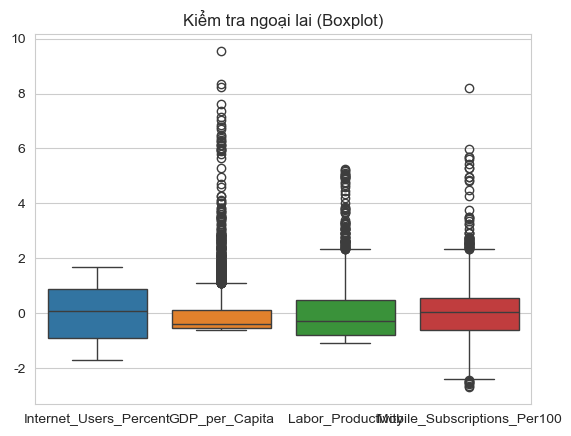

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=df[["Internet_Users_Percent","GDP_per_Capita","Labor_Productivity","Mobile_Subscriptions_Per100"]])
plt.title("Kiểm tra ngoại lai (Boxplot)")
plt.show()


# Phân tích mô tả (EDA)

## thống kê mô tả

In [ ]:

print("Số lượng quốc gia:", df["Country"].nunique())
print("Số năm:", df["Year"].nunique())
print("\nKiểu dữ liệu:")
print(df.dtypes)
print("\nThống kê mô tả:")
display(df.describe().round(2))


Số lượng quốc gia: 242
Số năm: 14

Kiểu dữ liệu:
Year                             int64
Country                         object
ISO3                            object
Internet_Users_Percent         float64
GDP_per_Capita                 float64
Labor_Productivity             float64
Mobile_Subscriptions_Per100    float64
dtype: object

Thống kê mô tả:


,Year,Internet_Users_Percent,GDP_per_Capita,Labor_Productivity,Mobile_Subscriptions_Per100
count,3388.00,3178.00,3388.00,3150.00,3388.00
mean,2016.50,-0.00,0.00,-0.00,0.00
std,4.03,1.00,1.00,1.00,1.00
min,2010.00,-1.72,-0.63,-1.08,-2.69
25%,2013.00,-0.92,-0.56,-0.79,-0.63
50%,2016.50,0.06,-0.40,-0.29,0.06
75%,2020.00,0.89,0.10,0.46,0.56
max,2023.00,1.67,9.55,5.25,8.22


## Kiểm tra phân phối từng biến

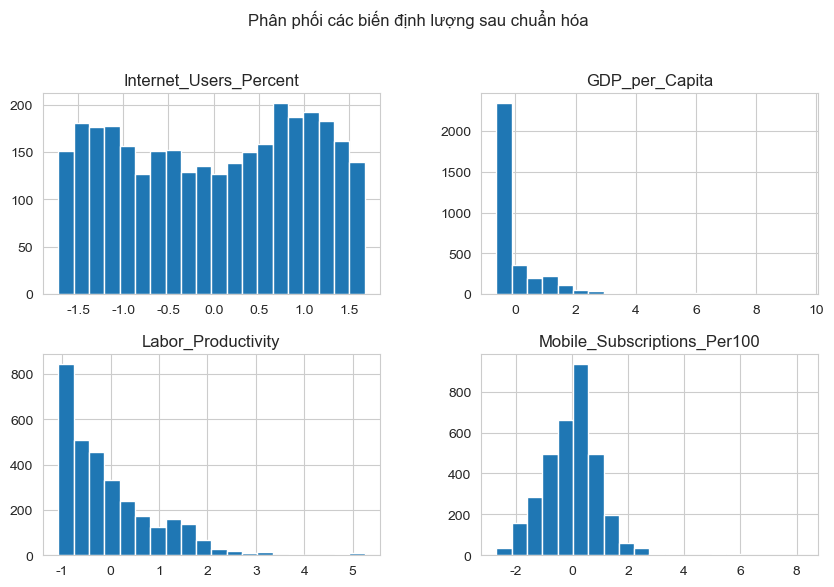

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = ["Internet_Users_Percent","GDP_per_Capita","Labor_Productivity","Mobile_Subscriptions_Per100"]

df[num_cols].hist(bins=20, figsize=(10,6))
plt.suptitle("Phân phối các biến định lượng sau chuẩn hóa", y=1.02)
plt.show()


##  MA TRẬN TƯƠNG QUAN


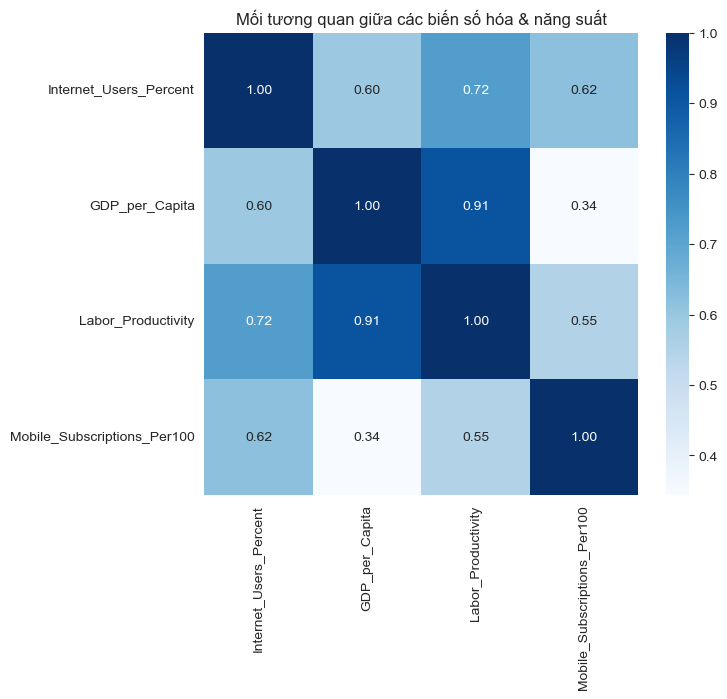

In [51]:
plt.figure(figsize=(7,6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="Blues", fmt=".2f")
plt.title("Mối tương quan giữa các biến số hóa & năng suất")
plt.show()


## QUAN HỆ CẶP BIẾN


EDA shape: (2940, 4)
Số giá trị thiếu sau xử lý: 0


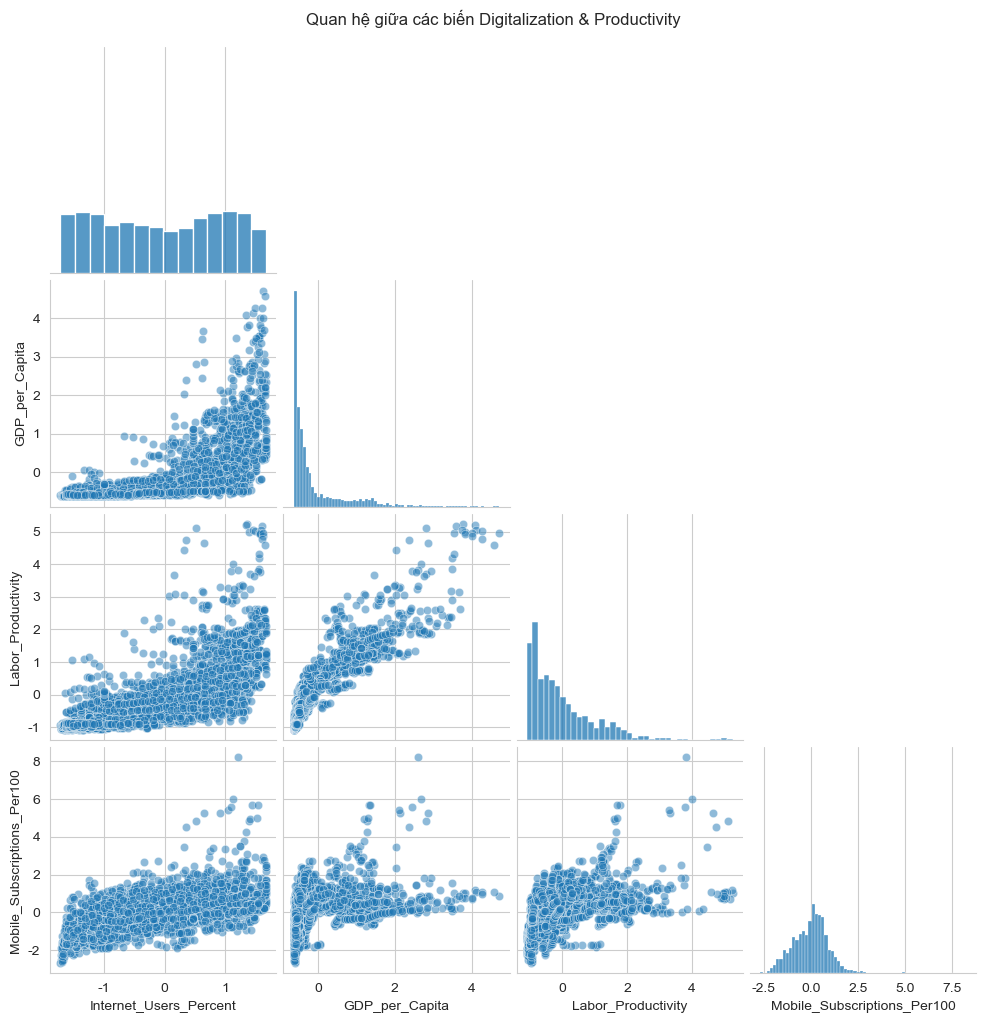

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Giữ 4 biến số chính
num_cols = ["Internet_Users_Percent","GDP_per_Capita",
            "Labor_Productivity","Mobile_Subscriptions_Per100"]

eda = df[num_cols].copy()
eda = eda.apply(pd.to_numeric, errors="coerce")          
eda = eda.replace([np.inf, -np.inf], np.nan)             
eda = eda.dropna(how="any").reset_index(drop=True)       
print("EDA shape:", eda.shape)
print("Số giá trị thiếu sau xử lý:", eda.isna().sum().sum())

# Vẽ pairplot
sns.pairplot(eda, diag_kind="hist", corner=True, plot_kws={"alpha":0.5})
plt.suptitle("Quan hệ giữa các biến Digitalization & Productivity", y=1.02)
plt.show()


## XU HƯỚNG THEO THỜI GIAN


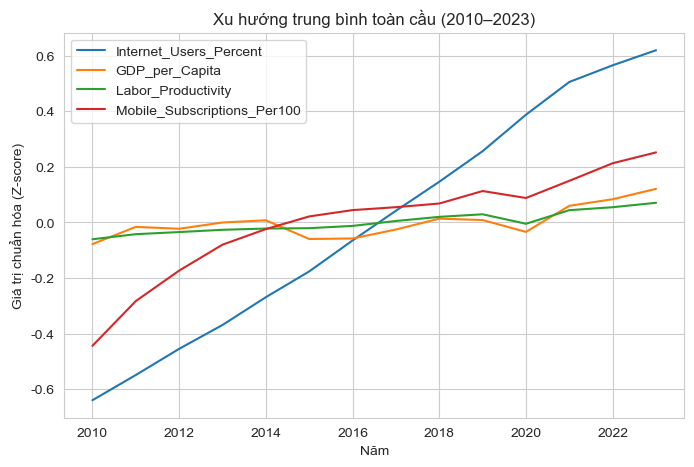

In [54]:
df_year = df.groupby("Year")[num_cols].mean().reset_index()

plt.figure(figsize=(8,5))
for col in num_cols:
    sns.lineplot(data=df_year, x="Year", y=col, label=col)
plt.title("Xu hướng trung bình toàn cầu (2010–2023)")
plt.xlabel("Năm")
plt.ylabel("Giá trị chuẩn hóa (Z-score)")
plt.legend()
plt.show()


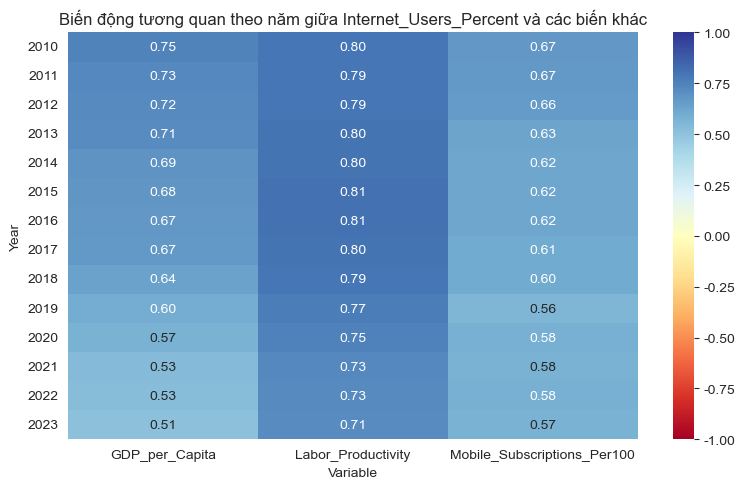

In [ ]:

import pandas as pd, seaborn as sns, matplotlib.pyplot as plt

focus = "Internet_Users_Percent"
num_cols = ["Internet_Users_Percent","GDP_per_Capita","Labor_Productivity","Mobile_Subscriptions_Per100"]

corr_rows = []
for year, g in df.groupby("Year"):
    c = g[num_cols].corr()
    cm = (c.reset_index()
           .melt(id_vars="index", var_name="var2", value_name="corr")
           .rename(columns={"index":"var1"}))
    cm["Year"] = year
    corr_rows.append(cm)

corr_by_year = pd.concat(corr_rows, ignore_index=True)

# Lọc tương quan với biến focus và pivot ra ma trận Year × biến_khác
corr_focus = corr_by_year[corr_by_year["var1"] == focus].copy()
pivot_corr = (corr_focus.pivot(index="Year", columns="var2", values="corr")
                        .reindex(sorted(df["Year"].unique()))
                        [ [c for c in num_cols if c != focus] ])  # giữ thứ tự cột đẹp

plt.figure(figsize=(8,5))
sns.heatmap(pivot_corr, annot=True, cmap="RdYlBu", fmt=".2f", vmin=-1, vmax=1)
plt.title(f"Biến động tương quan theo năm giữa {focus} và các biến khác")
plt.ylabel("Year"); plt.xlabel("Variable")
plt.tight_layout(); plt.show()


Quan hệ phi tuyến giữa các biến

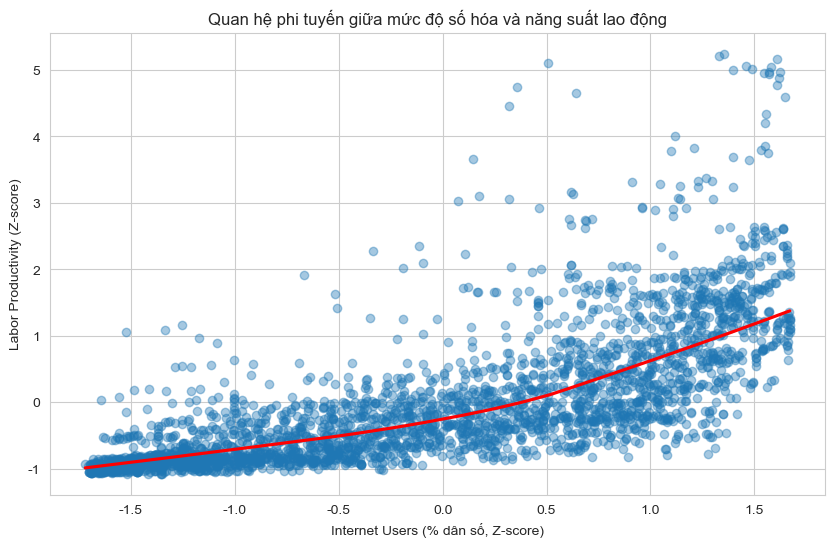

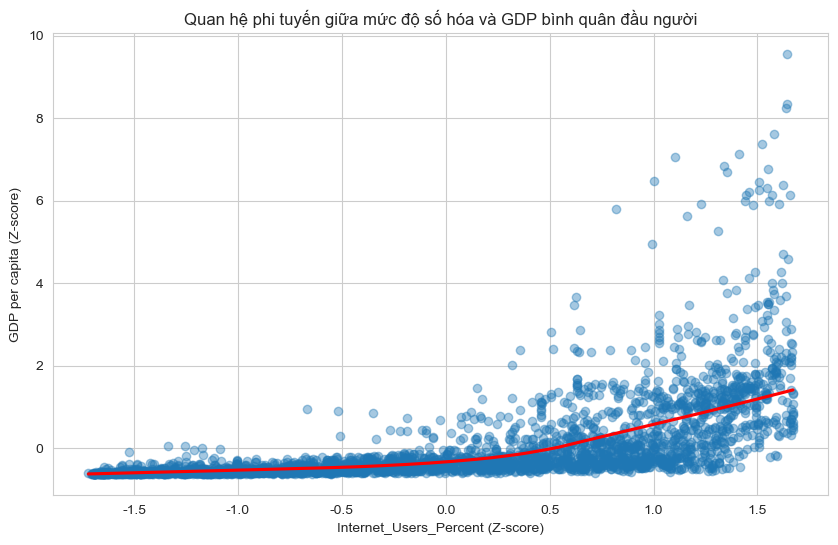

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.regplot(
    data=df, x="Internet_Users_Percent", y="Labor_Productivity",
    scatter_kws={"alpha":0.4}, line_kws={"color":"red"},
    lowess=True  
)
plt.title("Quan hệ phi tuyến giữa mức độ số hóa và năng suất lao động")
plt.xlabel("Internet Users (% dân số, Z-score)")
plt.ylabel("Labor Productivity (Z-score)")
plt.show()

plt.figure(figsize=(10,6))
sns.regplot(
    data=df, x="Internet_Users_Percent", y="GDP_per_Capita",
    scatter_kws={"alpha":0.4}, line_kws={"color":"red"},
    lowess=True
)
plt.title("Quan hệ phi tuyến giữa mức độ số hóa và GDP bình quân đầu người")
plt.xlabel("Internet_Users_Percent (Z-score)")
plt.ylabel("GDP per capita (Z-score)")
plt.show()


Tìm thấy file metadata: ['Metadata_Country_API_IT.CEL.SETS.P2_DS2_en_csv_v2_123929.csv', 'Metadata_Country_API_IT.NET.USER.ZS_DS2_en_csv_v2_129784.csv', 'Metadata_Country_API_NY.GDP.PCAP.CD_DS2_en_csv_v2_134819.csv', 'Metadata_Country_API_SL.GDP.PCAP.EM.KD_DS2_en_csv_v2_4378.csv']
Số quốc gia có thông tin Region: 2716
Số quốc gia có thông tin IncomeGroup: 2702


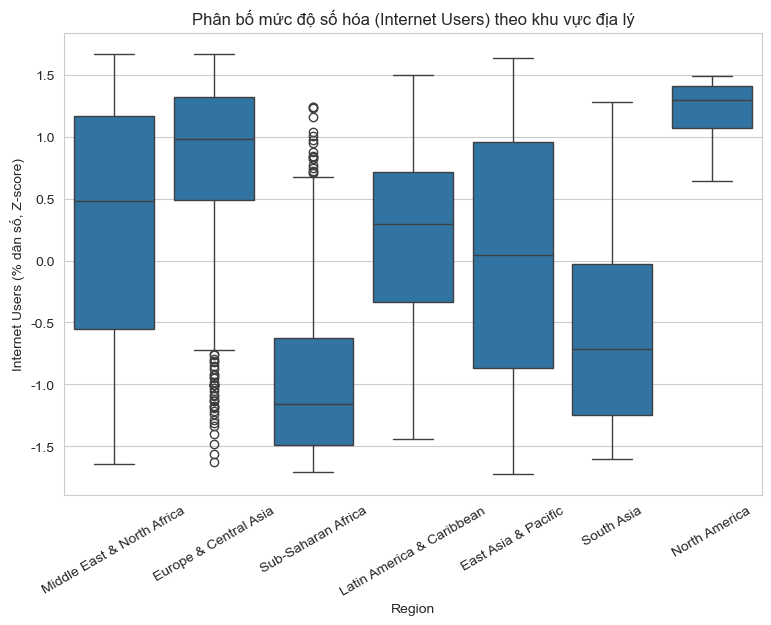

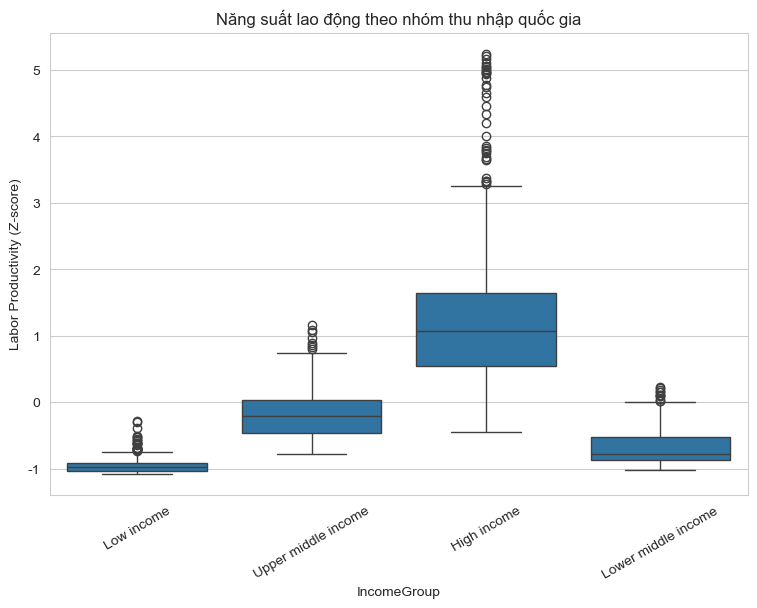

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
DATA_DIR = Path("wb_csv")
meta_files = sorted(DATA_DIR.glob("Metadata_Country_API_*.csv"))
print("Tìm thấy file metadata:", [f.name for f in meta_files])
meta_list = []
for fp in meta_files:
    try:
        temp = pd.read_csv(fp, encoding="utf-8-sig")
        temp = temp.rename(columns={"Country Code": "ISO3"})
        meta_list.append(temp[["ISO3", "Region", "IncomeGroup"]])
    except Exception as e:
        print("Lỗi khi đọc", fp.name, ":", e)


meta_all = pd.concat(meta_list).drop_duplicates(subset="ISO3")


df = df.merge(meta_all, on="ISO3", how="left")

print("Số quốc gia có thông tin Region:", df["Region"].notna().sum())
print("Số quốc gia có thông tin IncomeGroup:", df["IncomeGroup"].notna().sum())

plt.figure(figsize=(9,6))
sns.boxplot(data=df, x="Region", y="Internet_Users_Percent")
plt.title("Phân bố mức độ số hóa (Internet Users) theo khu vực địa lý")
plt.xticks(rotation=30)
plt.ylabel("Internet Users (% dân số, Z-score)")
plt.show()

plt.figure(figsize=(9,6))
sns.boxplot(data=df, x="IncomeGroup", y="Labor_Productivity")
plt.title("Năng suất lao động theo nhóm thu nhập quốc gia")
plt.xticks(rotation=30)
plt.ylabel("Labor Productivity (Z-score)")
plt.show()


# •	Phân cụm / phân nhóm (Clustering/Classification): 

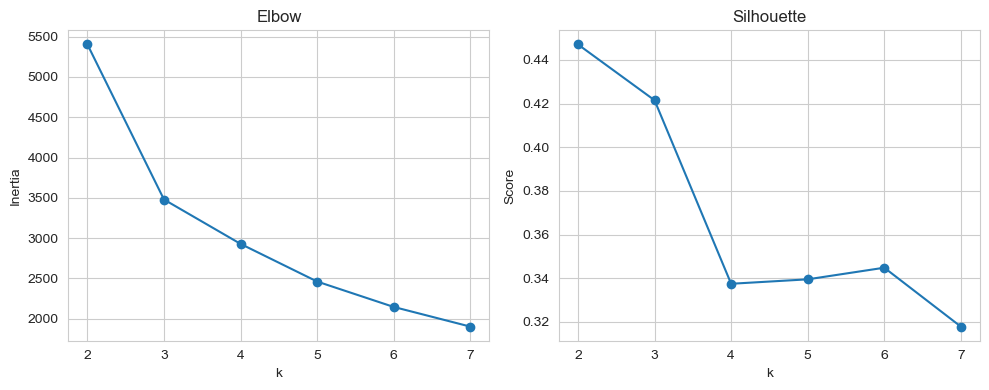

best_k = 2


In [58]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np, matplotlib.pyplot as plt

num_cols = ["Internet_Users_Percent","GDP_per_Capita","Labor_Productivity","Mobile_Subscriptions_Per100"]
mask = df[num_cols].notna().all(axis=1)
X = df.loc[mask, num_cols].to_numpy()

inertia, silhouette, K = [], [], range(2, 8)
for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    lab = km.fit_predict(X)
    inertia.append(km.inertia_)
    silhouette.append(silhouette_score(X, lab))

plt.figure(figsize=(10,4))
plt.subplot(1,2,1); plt.plot(K, inertia, 'o-'); plt.title("Elbow"); plt.xlabel("k"); plt.ylabel("Inertia")
plt.subplot(1,2,2); plt.plot(K, silhouette, 'o-'); plt.title("Silhouette"); plt.xlabel("k"); plt.ylabel("Score")
plt.tight_layout(); plt.show()

best_k = K[int(np.argmax(silhouette))]  # hoặc đặt tay, ví dụ 3
print("best_k =", best_k)


Đặc trưng trung bình từng cụm:


,Internet_Users_Percent,GDP_per_Capita,Labor_Productivity,Mobile_Subscriptions_Per100
Cluster,,,,
0,0.94,0.54,0.88,0.75
1,-0.70,-0.51,-0.62,-0.49


Số điểm dùng huấn luyện theo cụm:
Cluster
1    1749
0    1191
Name: count, dtype: Int64


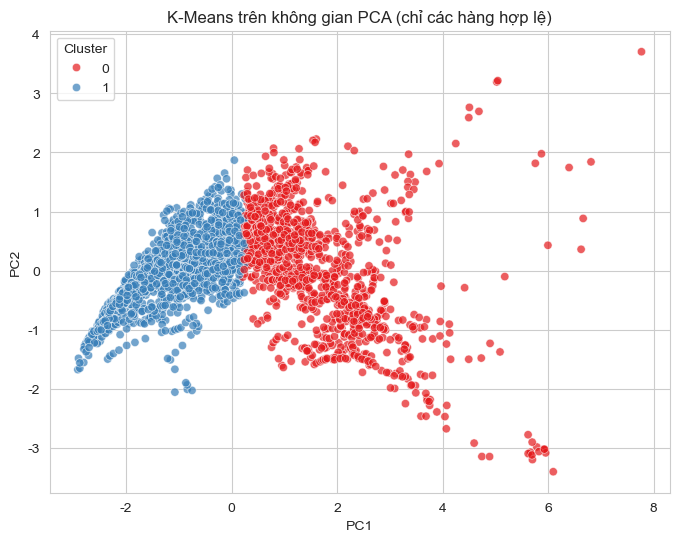

In [60]:
from sklearn.decomposition import PCA
import seaborn as sns

pca = PCA(n_components=2, random_state=42)
pcs = pca.fit_transform(X)
plot_df = df.loc[mask, ["Country","Year"]].copy()
plot_df["PC1"], plot_df["PC2"], plot_df["Cluster"] = pcs[:,0], pcs[:,1], labels

plt.figure(figsize=(8,6))
sns.scatterplot(data=plot_df, x="PC1", y="PC2", hue="Cluster", palette="Set1", alpha=0.7)
plt.title("K-Means trên không gian PCA (chỉ các hàng hợp lệ)")
plt.legend(title="Cluster"); plt.show()
